# Esperimento dense reward

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import ast

In [2]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_wo_edge.csv"
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
 'qwen_chat_agent_13_dense_reward_51_step',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

In [3]:
sns.set_theme(style="darkgrid")
colors = edgecolors = sns.color_palette("muted")

# global attribute
# per le lettere
offset = 5
plt.rcParams["font.family"] = "DIN Alternate"
plt.rcParams["axes.titlesize"] = 20 + offset
plt.rcParams["axes.labelsize"] = 15 + offset
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"]   = 15 + offset
plt.rcParams["ytick.labelsize"]   = 15 + offset
plt.rcParams["legend.fontsize"]   = 15 + offset
plt.rcParams["legend.title_fontsize"] = 15 + offset

# per il colore del grafico 
plt.rcParams["axes.facecolor"] = "white"
#plt.rcParams["figure.facecolor"] =  "#ca6702"
plt.rcParams["grid.color"] = "#fed0bb"
plt.rcParams["axes.edgecolor"] = "#fed0bb"


In [4]:
target ='base|qwen-chat-agent-5-v1|qwen_chat_agent_13_dense_reward_51_step|qwen_chat_agent_sft'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['Qwen3:4b','Agent-Sparse','Agent-Dense','Agent-SFT']
models

['chat-qwen-base',
 'qwen-chat-agent-5-v1',
 'qwen_chat_agent_13_dense_reward_51_step',
 'qwen_chat_agent_sft']

0.46 	+-0.0203571170187945
0.78 	+-0.01856006949138991
0.899 	+-0.013695275944172242
0.497 	+-0.020958863478143432


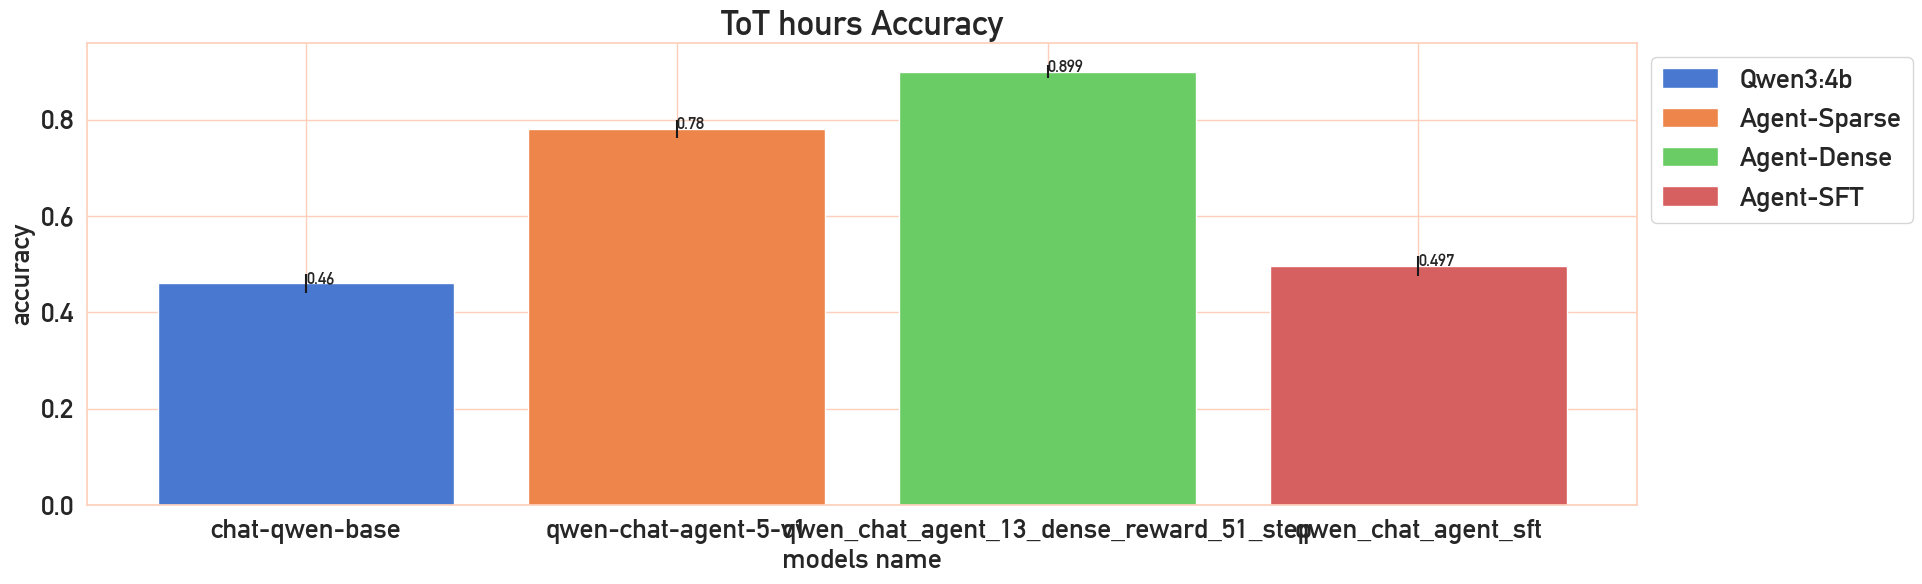

In [5]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    g = df.loc[df['model'] == model]
    acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
      )                                                                                                                                                                                                                                                                                                      
    # effective n = total field evaluations (not number of rows)                                                                                          
    n = g['n_relevant_fields'].sum()
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")
        
plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

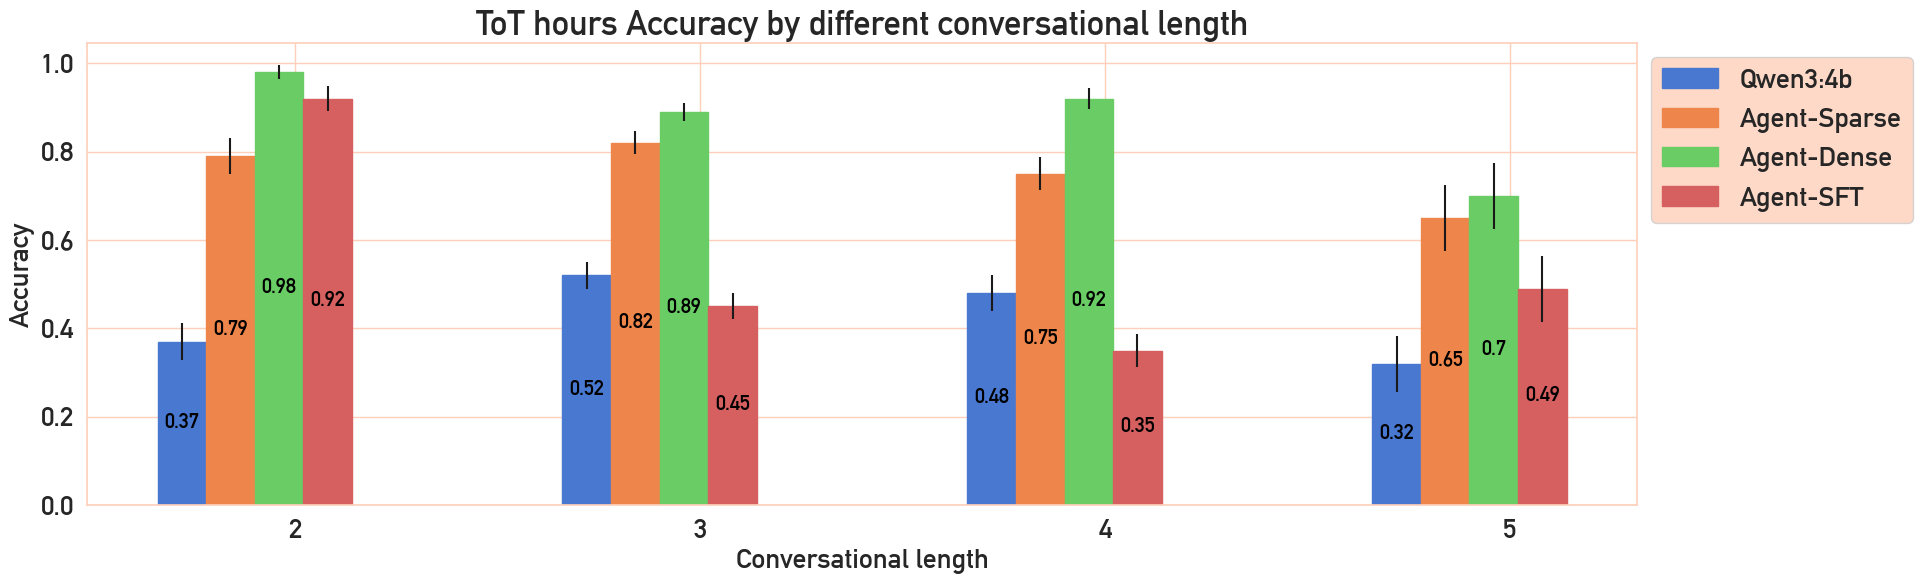

In [8]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

models = list(df[df['model'].str.contains(target)]['model'].unique())

l_msg = np.sort(df['L_MESSAGGI'].unique())
x = np.arange(len(l_msg))  # the label locations
width = 0.12  # the width of the bars
multiplier = 0
fig, ax = plt.subplots(figsize=(20,6))

for model,label,color in zip(models,labels,colors):
    media_group = []
    CI_group = []
    
    for length_m in l_msg:
        g = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]
        
        acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          2                                                                                                                                                 
        )                                                                                                                                                                                                                                                                                                      
        # effective n = total field evaluations (not number of rows)                                                                                          
        n = g['n_relevant_fields'].sum()
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    offset = width * multiplier
    rects = ax.bar(x + offset, media_group, width, yerr=CI_group, label=label, color=color, edgecolor=color)
    ax.bar_label(rects, padding=1, label_type='center',color="black",size=15, weight="bold")
    multiplier += 1


n_metrics = len(l_msg)
center_offset = width * (n_metrics - 1) / 2 + 0.10

ax.set_title(f"ToT hours Accuracy by different conversational length")
ax.set_xlabel("Conversational length")
ax.set_xticks(x + center_offset, l_msg)
ax.set_ylabel("Accuracy")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

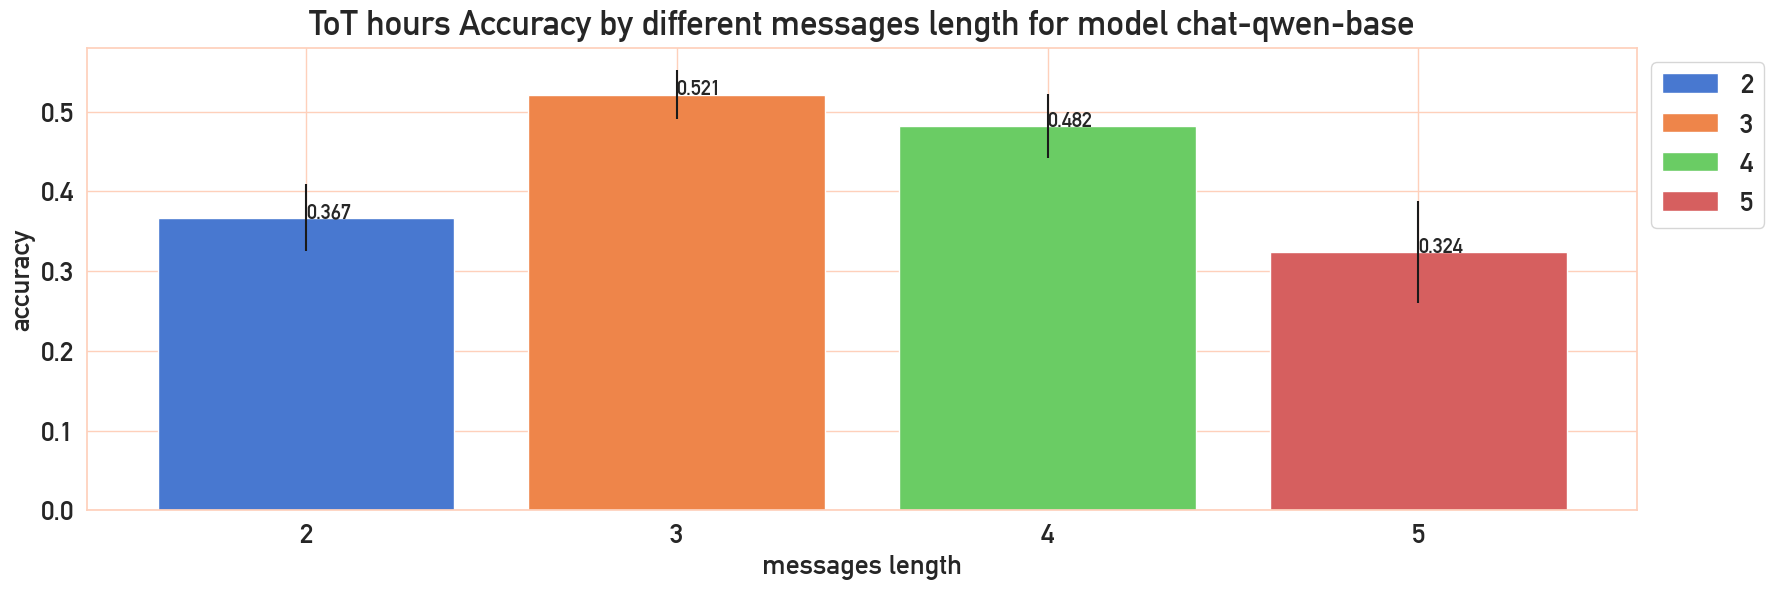

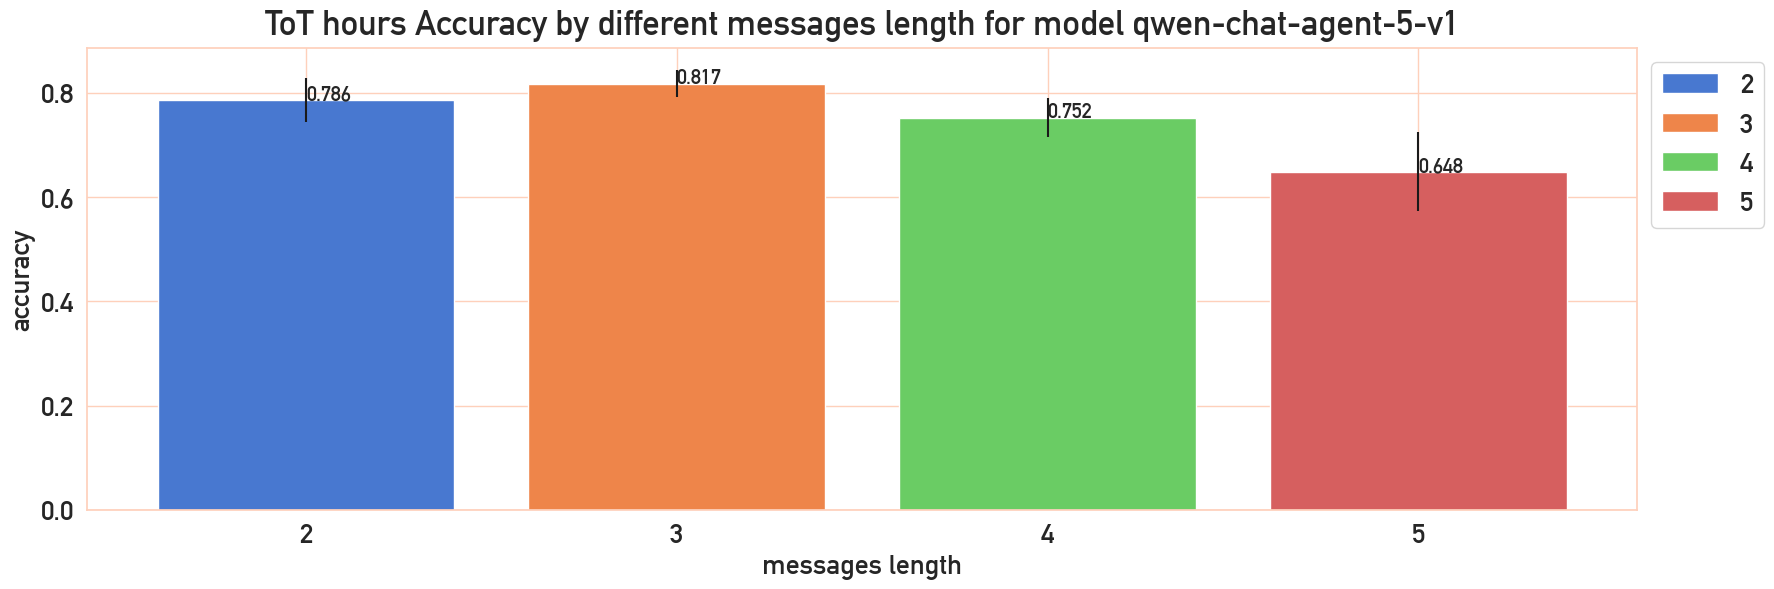

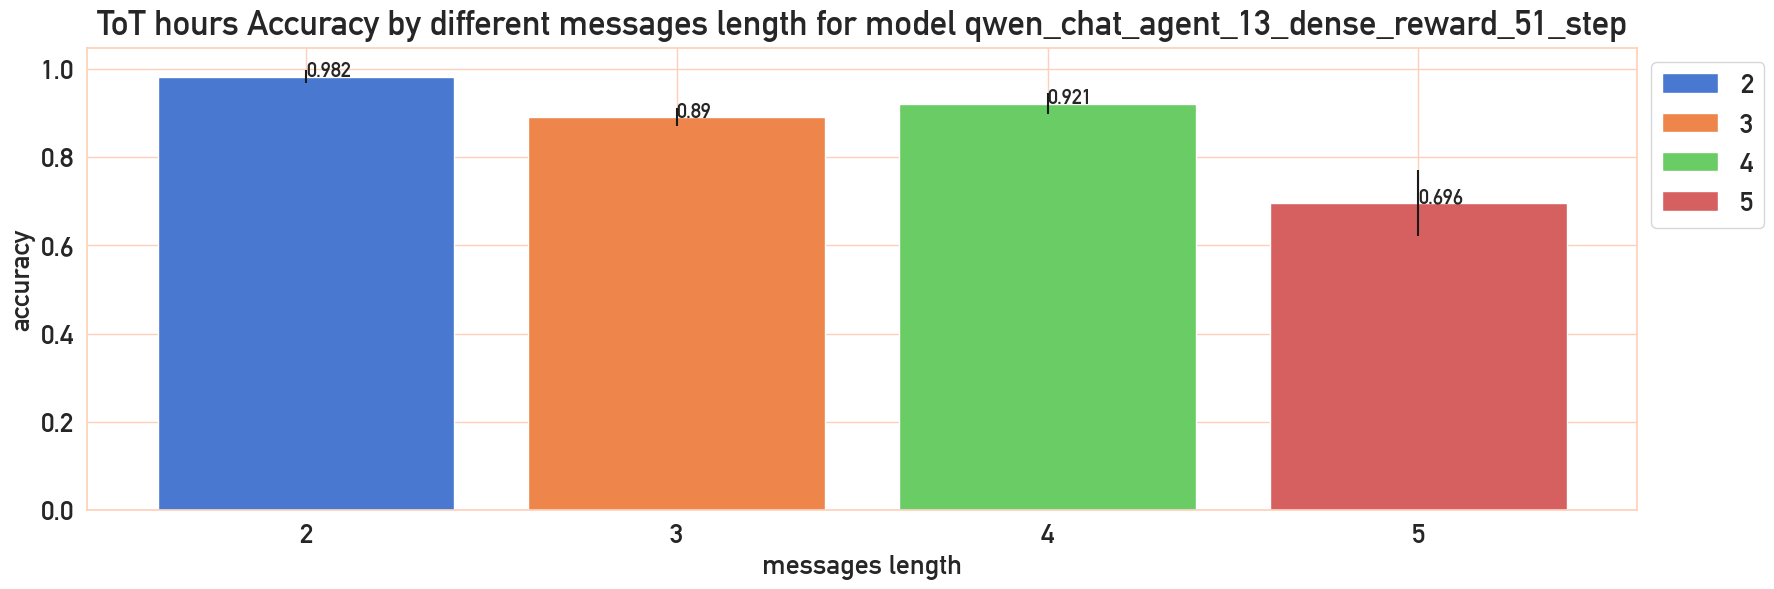

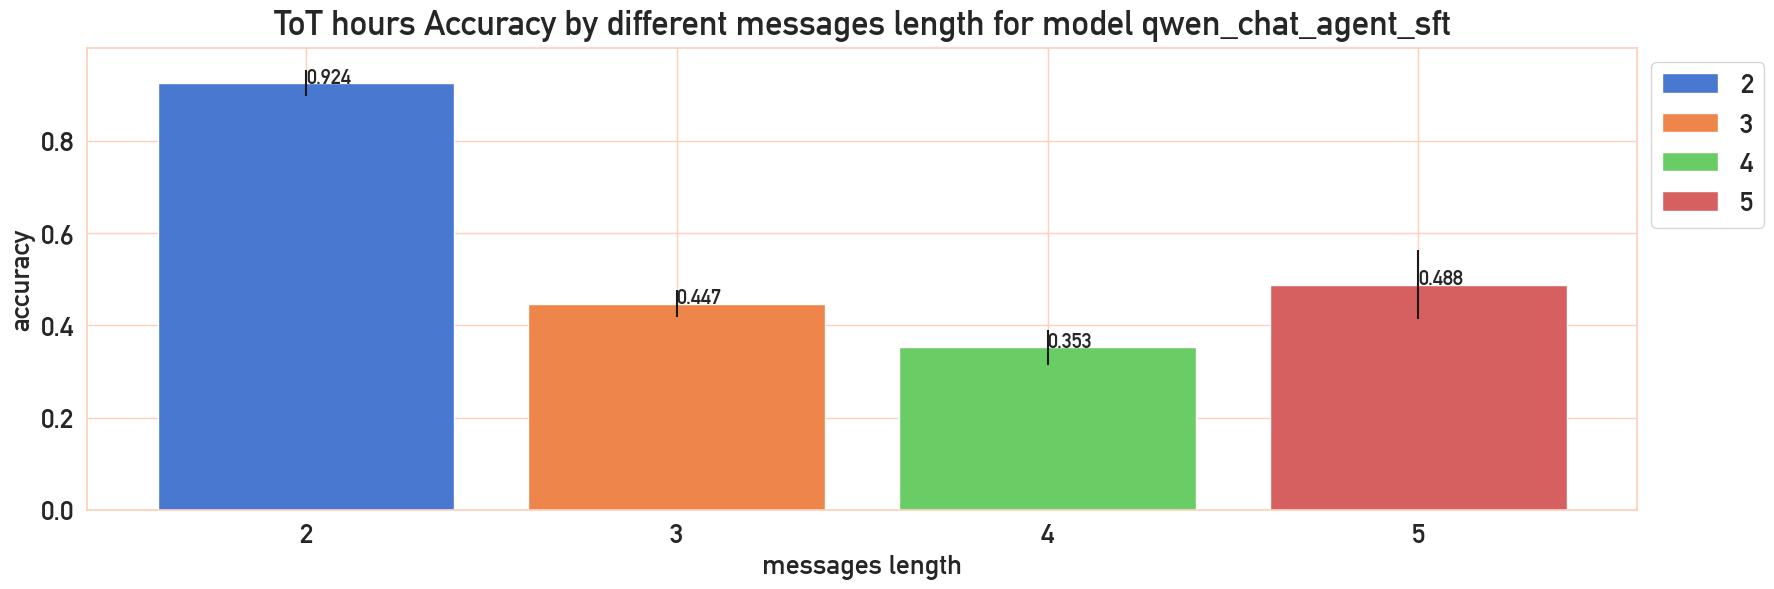

In [7]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    l_msg = np.sort(df['L_MESSAGGI'].unique())
    for length_m in l_msg:
        g = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]
        
        acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
        )                                                                                                                                                                                                                                                                                                      
        # effective n = total field evaluations (not number of rows)                                                                                          
        n = g['n_relevant_fields'].sum()
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, label=l_msg, color=colors)
    add_labels(l_msg,media_group)
    plt.title(f"ToT hours Accuracy by different messages length for model {model}", pad=10)
    plt.xlabel("messages length")
    plt.xticks(l_msg)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True)


In [7]:
colors = edgecolors = sns.color_palette("muted")

0.5 	+-0.03383312912010253
0.48 	+-0.033806051781535174
0.54 	+-0.03372468932474785
0.26 	+-0.02968073802677209
0.28 	+-0.03038207459757796
0.85 	+-0.024161687012486114
0.78 	+-0.02803049735066947
0.82 	+-0.025996527491654837
0.83 	+-0.025417666009035327
0.64 	+-0.032479803955298425
0.31 	+-0.03129518722830752
0.79 	+-0.027561024354181337
0.9 	+-0.020299877472061512
0.91 	+-0.019364848904560205
0.94 	+-0.016069845961880873
0.81 	+-0.026545534340092214
0.29 	+-0.030704380202521288
0.76 	+-0.028899117370113112
0.6 	+-0.03314956109837999
0.49 	+-0.033826361817480555
0.52 	+-0.033806051781535174
0.29 	+-0.030704380202521288
0.3 	+-0.031008575038016902
0.77 	+-0.02847616117911882


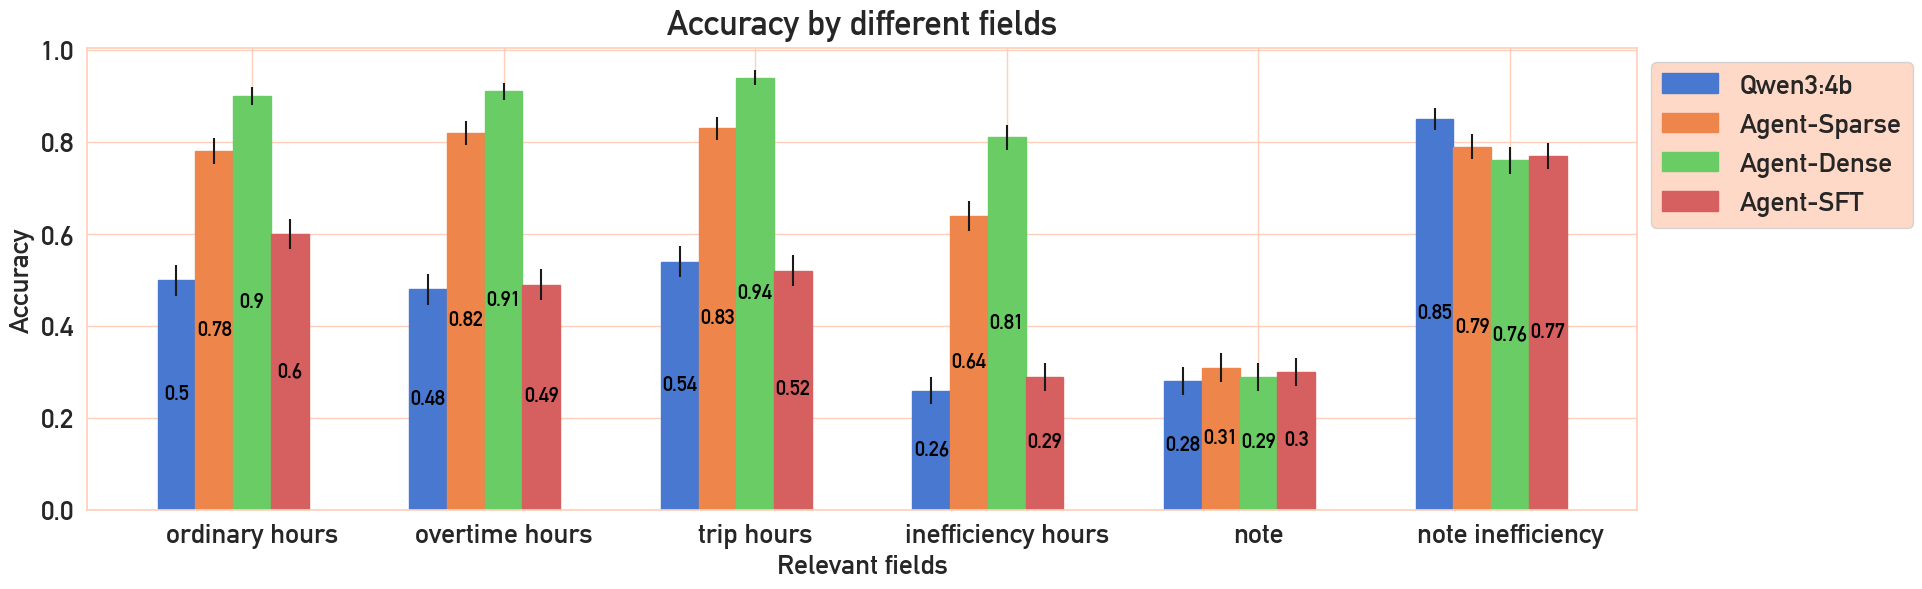

In [9]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label ,vals[i], vals[i], size=20)


fig, ax = plt.subplots(figsize=(20, 6))

fields=['ordinary hours', 'overtime hours', 'trip hours','inefficiency hours','note','note inefficiency']
columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
x = np.arange(len(fields))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0


for model,label,color in zip(models,labels,colors):
    media_group = []
    CI_group = []
    
    
    for column in columns:
        g = df.loc[(df['model'] == model)]
        acc_media = round(g[column].mean(),2)
        n = len(g)
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")

    offset = width * multiplier

    rects = ax.bar(x + offset,media_group, width, yerr=CI_group, label=label,color=color, edgecolor=color)
    ax.bar_label(rects, padding=1, label_type='center',color="black",size=15, weight="bold")
    multiplier += 1
    ax.set_title(f"Accuracy by different fields", pad=10)
    ax.set_xlabel("Relevant fields")
    offset = width * 2
    ax.set_xticks(x + offset, fields)
    ax.set_ylabel("Accuracy")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

plt.show()

0.499 	+-0.03383306145377662
0.477 	+-0.03379731471363948
0.536 	+-0.033745319700545846
0.262 	+-0.029754385702412324
0.281 	+-0.030415136298102444
0.851 	+-0.024095174513040465
0.775 	+-0.028256233589690025
0.815 	+-0.026274643395777918
0.831 	+-0.025358060055366494
0.639 	+-0.03249946351177661
0.307 	+-0.031211020353353748
0.788 	+-0.027656881000334557
0.897 	+-0.02056775998713338
0.915 	+-0.018870880815862762
0.935 	+-0.016681482553855494
0.808 	+-0.026651917274677327
0.291 	+-0.030735605547154165
0.757 	+-0.029021726057828375
0.599 	+-0.033163301506236836
0.486 	+-0.03381986393300098
0.519 	+-0.03380869277617078
0.29 	+-0.030704380202521288
0.3 	+-0.031008575038016902
0.769 	+-0.02851946154696708


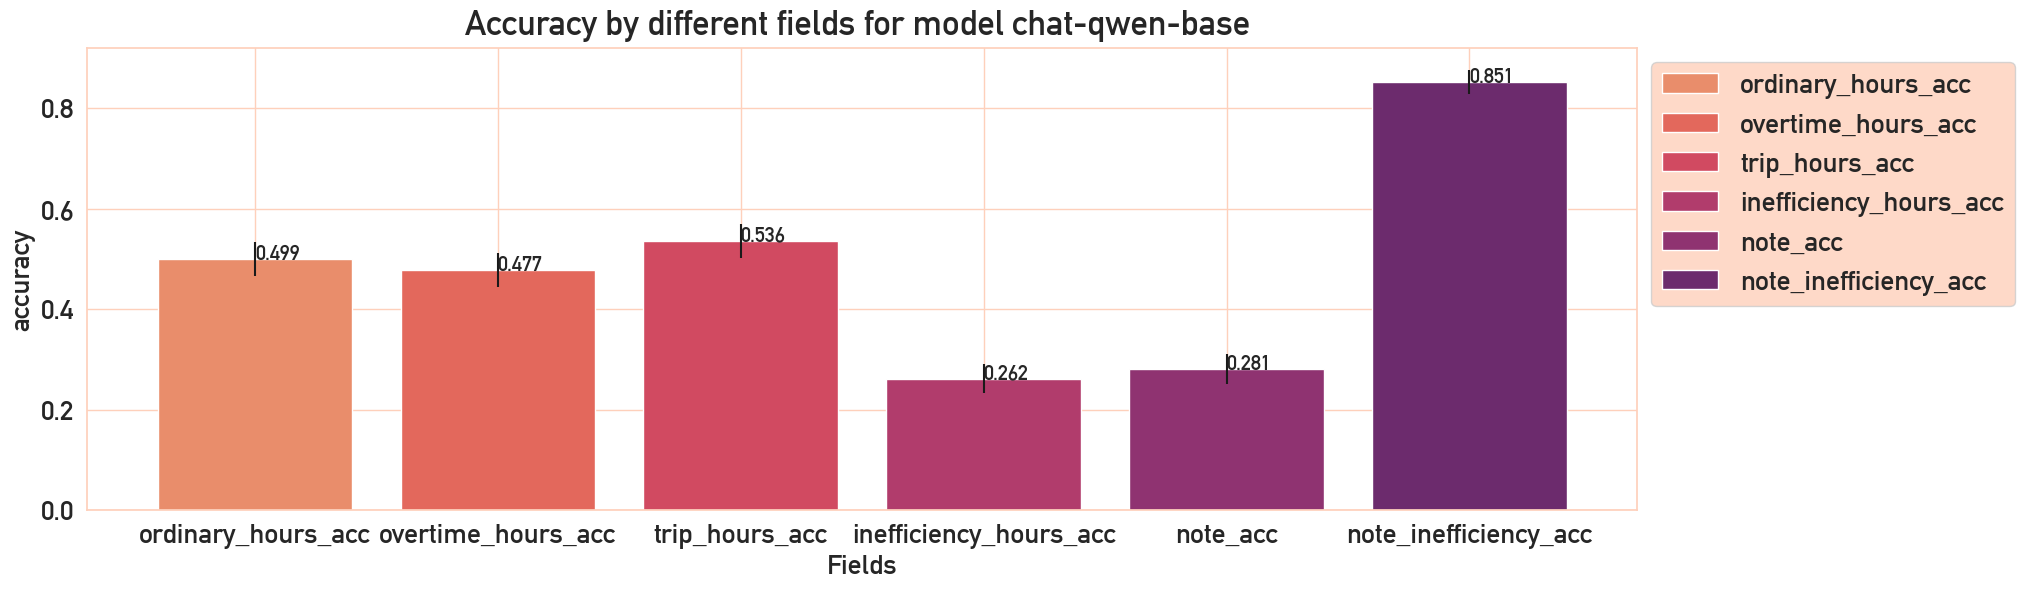

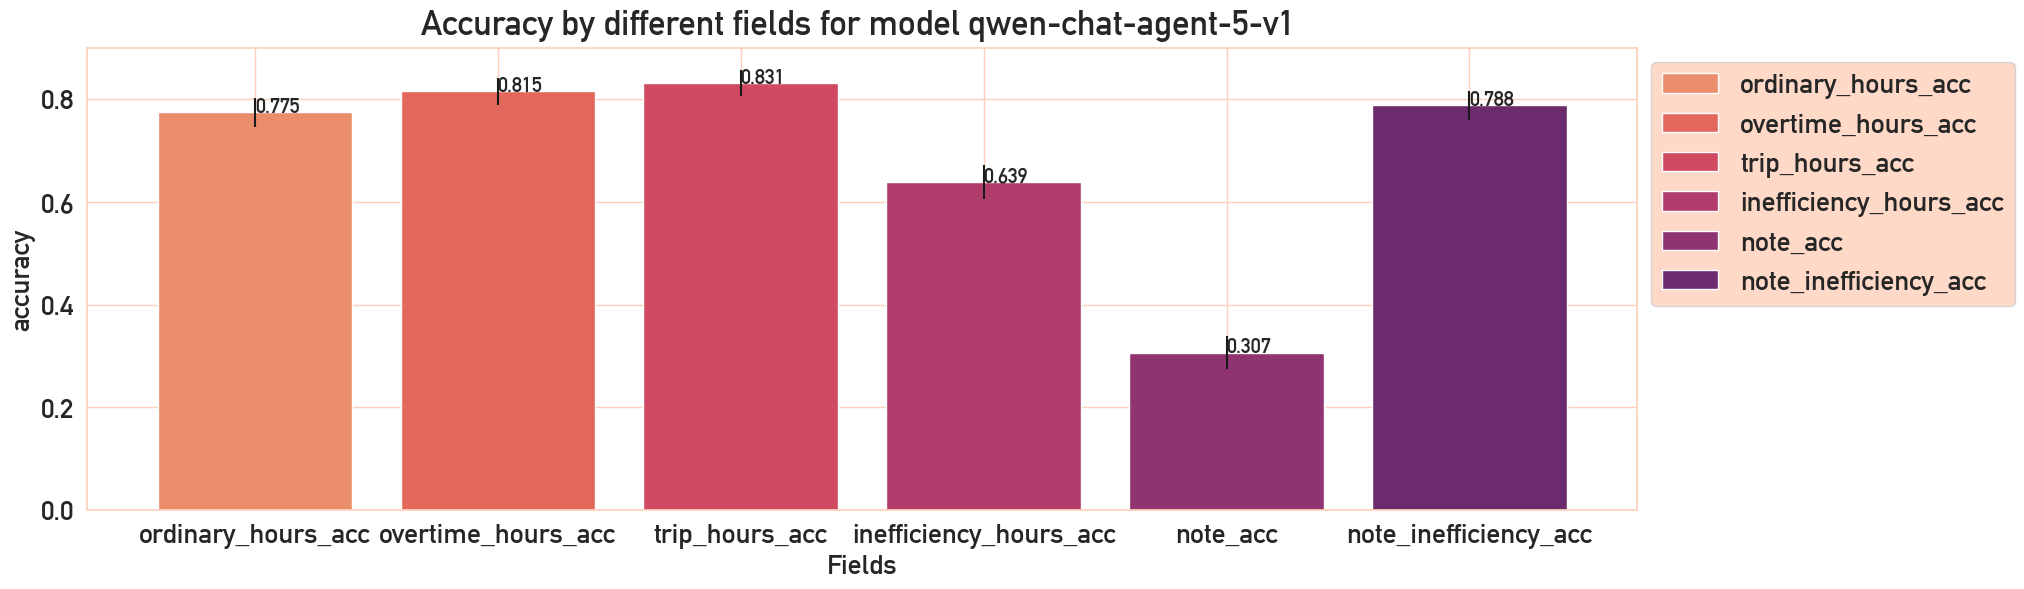

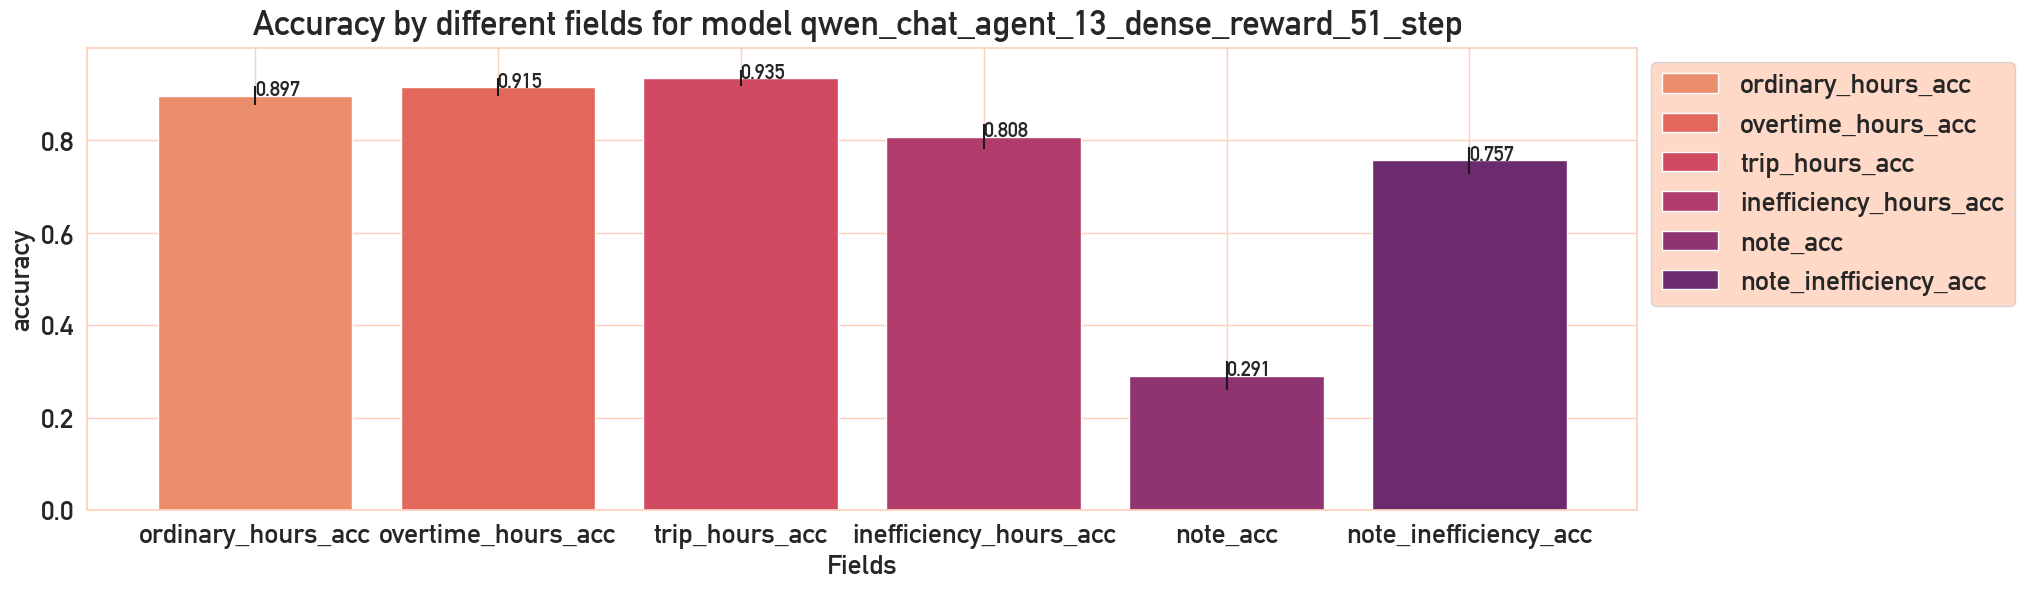

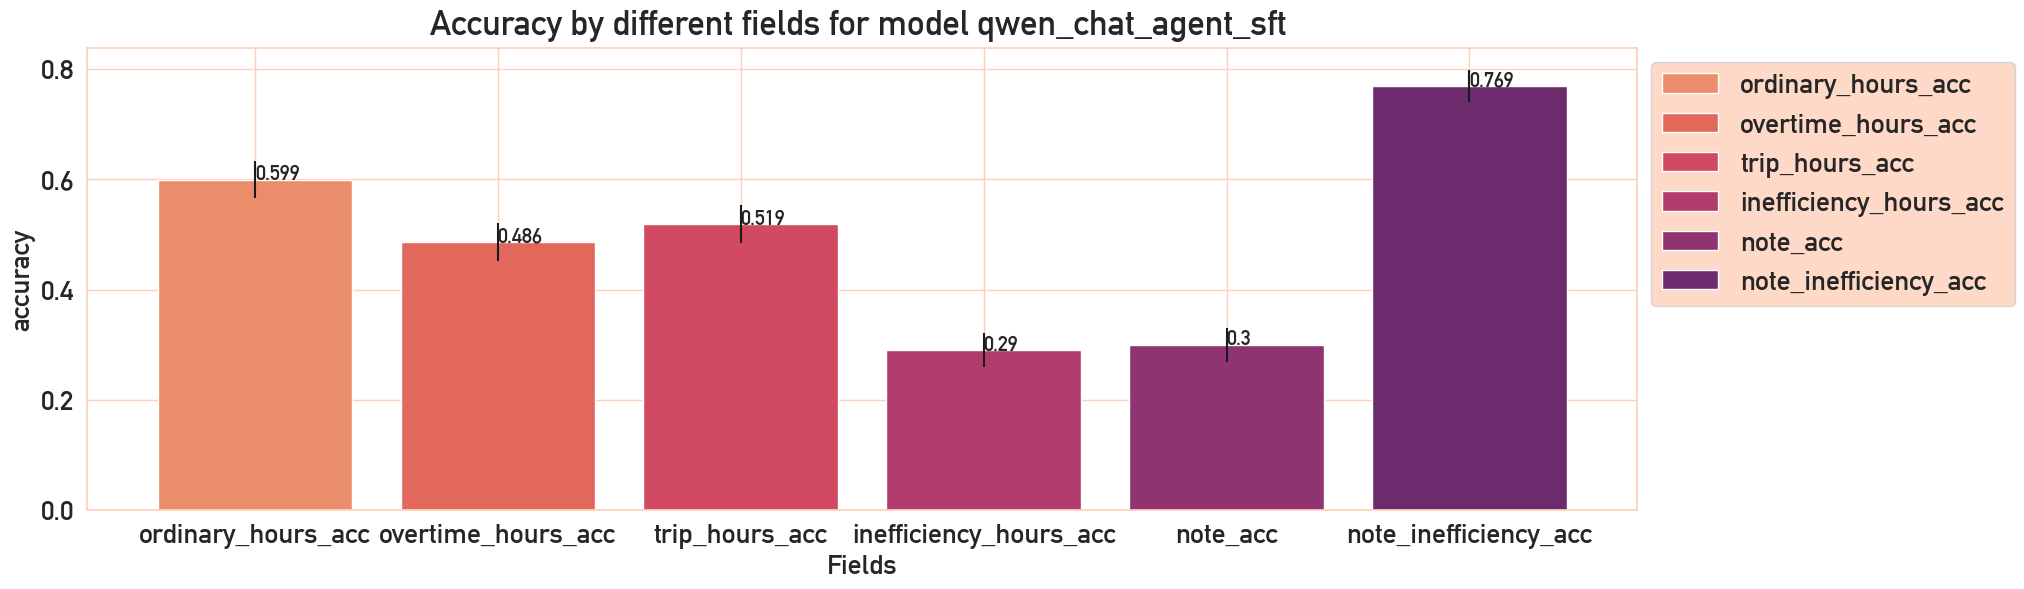

In [ ]:
# chart per il display tot per ogni misurazione
# accuracy a tipi di schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i], size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())


for model in models:
    media_group = []
    CI_group = []
    
    
    for column in columns:
            
        acc_media = round(df.loc[(df['model'] == model)][column].mean(),3)
        n = len(df.loc[(df['model'] == model)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")
    plt.figure(figsize=(20,6))
    plt.bar(fields,media_group, yerr=CI_group, label=fields, color=colors)
    add_labels(fields,media_group)
    plt.title(f"Accuracy by different fields for model {model} ", pad=10)
    plt.xlabel("Fields")
    plt.xticks(fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


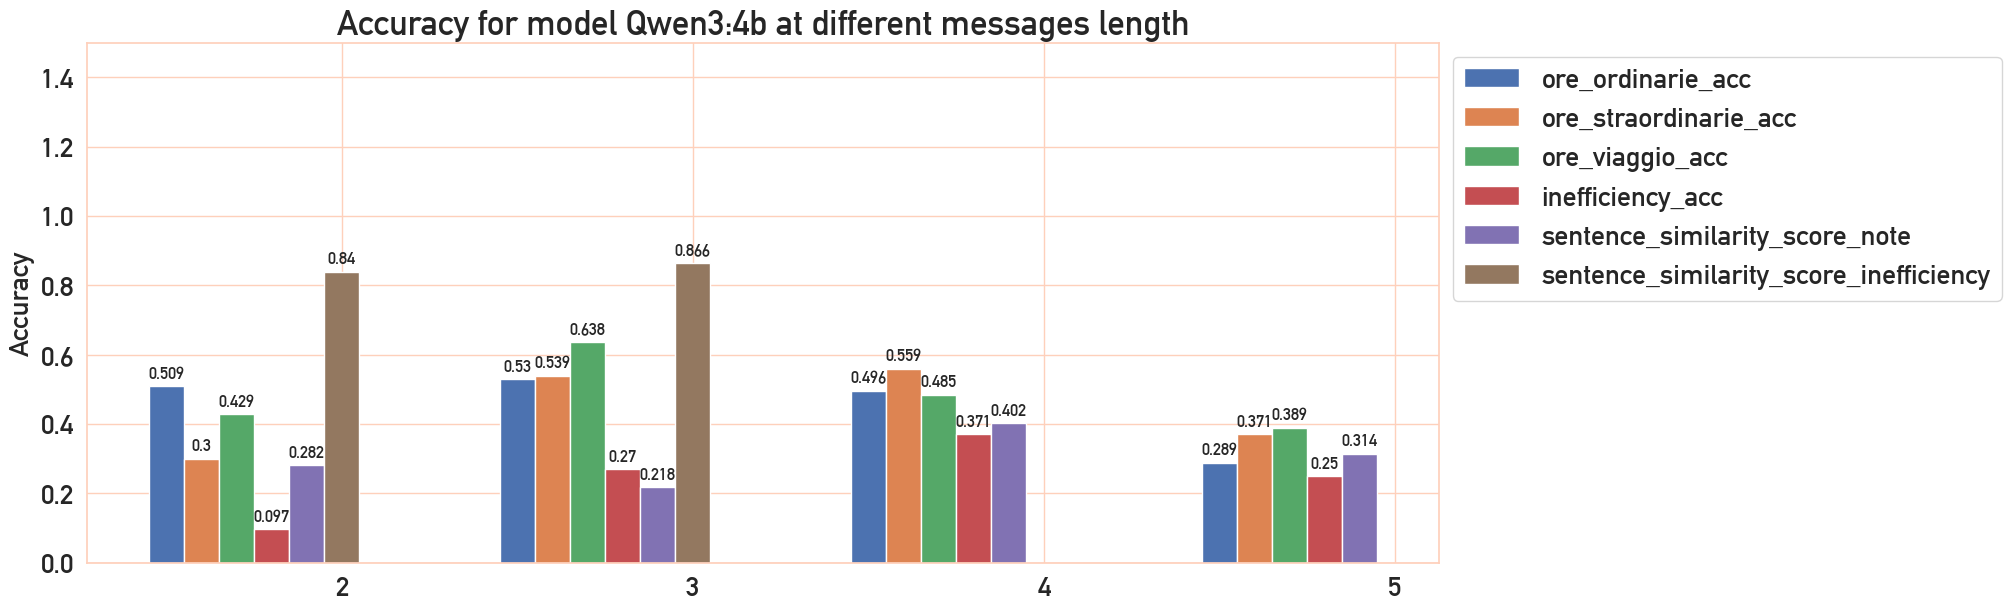

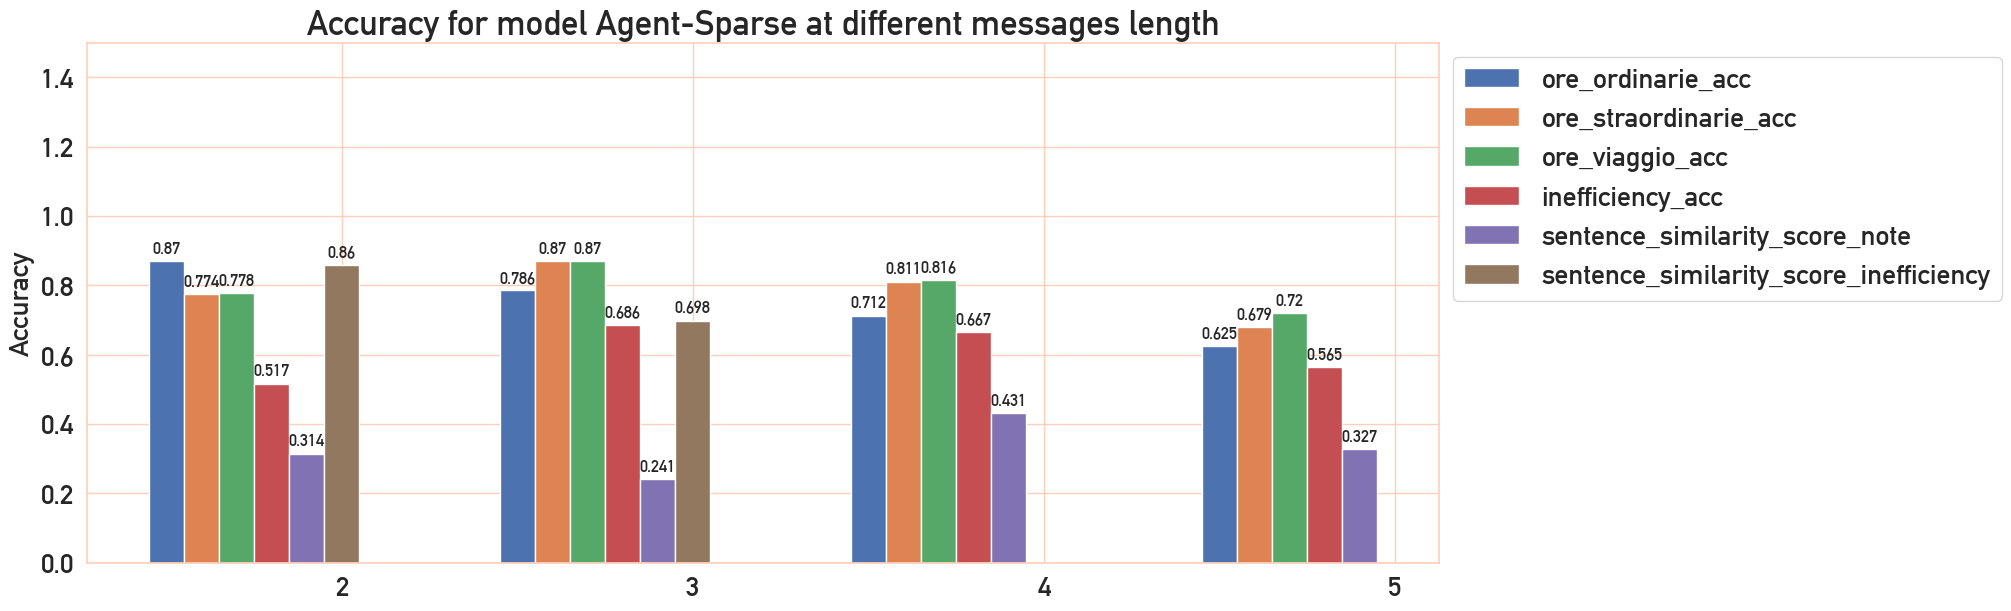

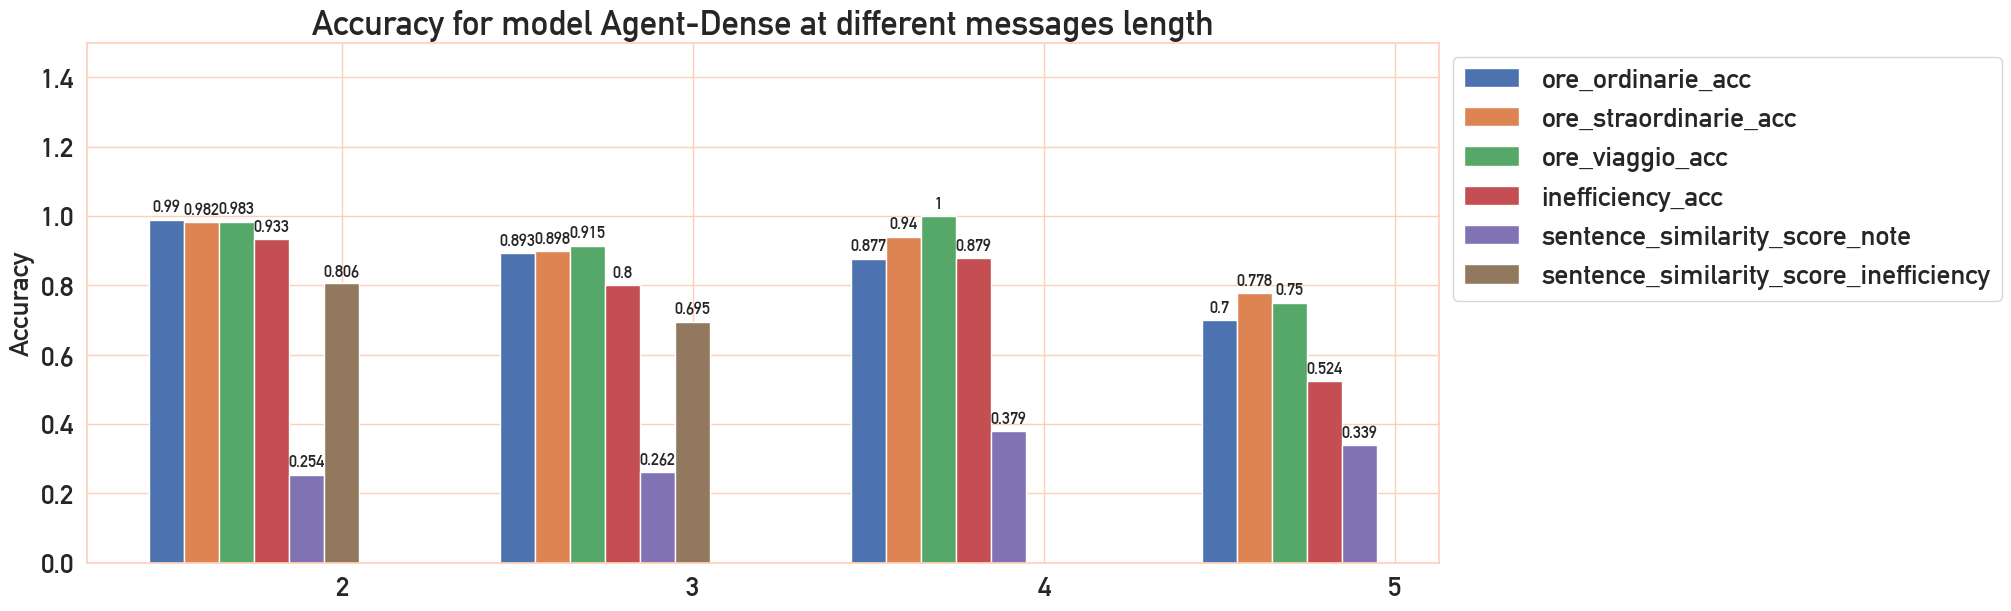

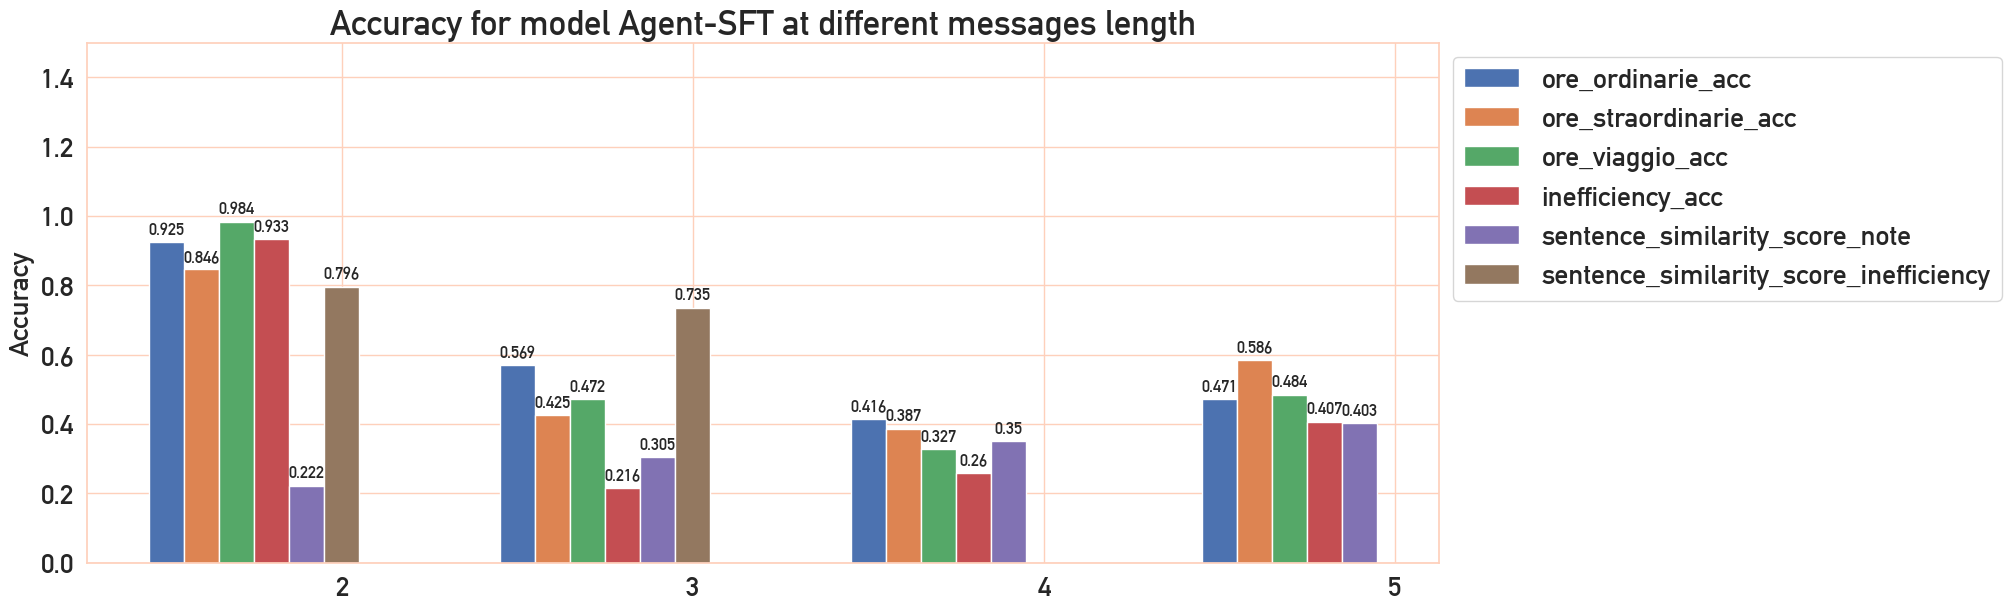

In [9]:
# chart per fare il display accuracy totale  al variare del flow

l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

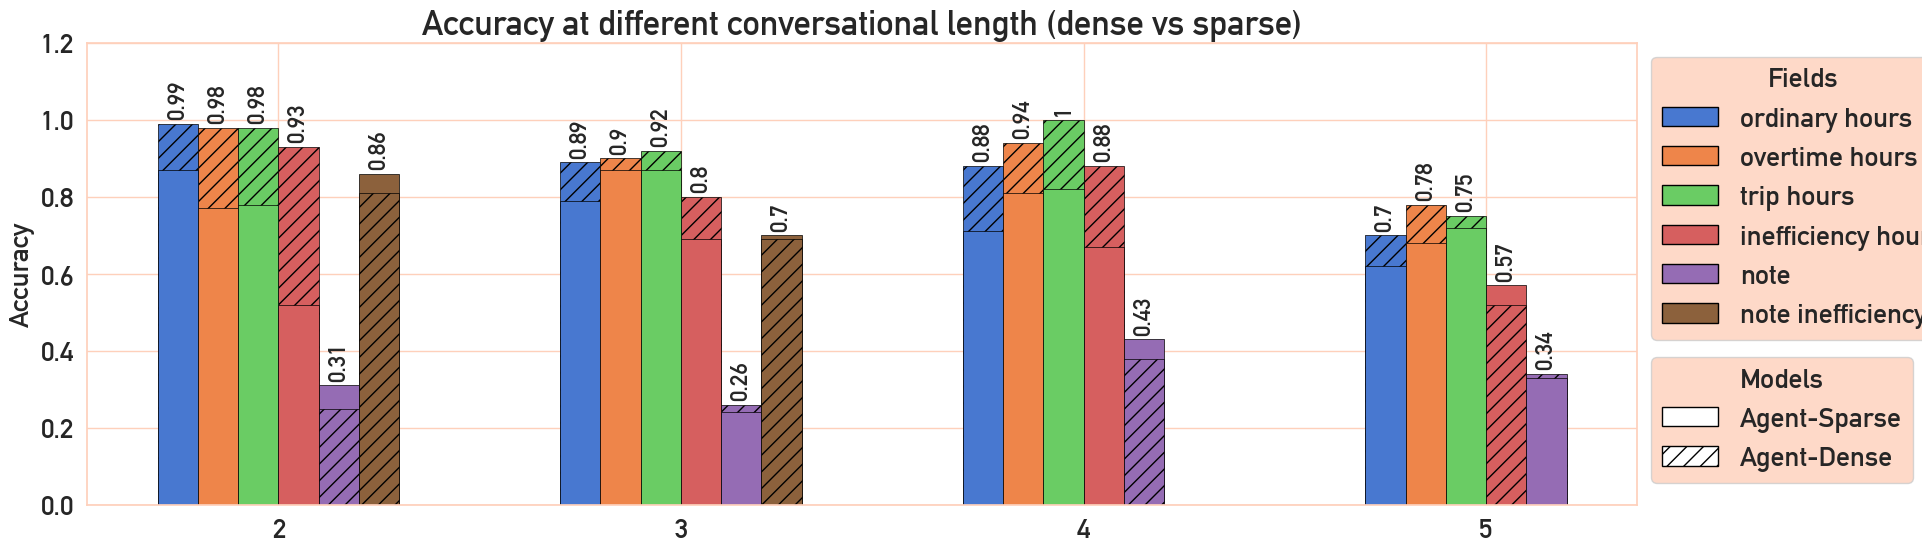

In [63]:
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties
# chart per fare il display accuracy totale al variare del flow tra dense e sparse nello stesso grafico

filter_el = ['Agent-Sparse','Agent-Dense']
l_msg = np.sort(df['L_MESSAGGI'].unique())

fig, ax = plt.subplots(figsize=(20,6))

fields=['ordinary hours', 'overtime hours', 'trip hours','inefficiency hours','note','note inefficiency']
columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
x = np.arange(len(l_msg))  # the label locations
width = 0.10  # the width of the bars

# un colore per ogni campo
colors = sns.color_palette("muted")
color_map = {col: colors[i] for i, col in enumerate(columns)}

# il secondo modello ha il retino e sta in secondo piano
model_hatches = {filter_el[0]: '', filter_el[1]: '//'}

metric_means = {}
for model,label in zip(models,labels):

    if label in filter_el:
        metric_per_model = {}

        # init il dict
        for column in columns:
            metric_per_model[column] = ()

        for length_m in l_msg:
            for column in columns:
                if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                    ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),2),)
                    metric_per_model[column] += ris
                else:
                    ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),2),)
                    metric_per_model[column] += ris

        metric_means[label] = metric_per_model

# ordine di disegno: prima il secondo modello (sfondo), poi il primo (davanti)
# l'offset dipende SOLO dal campo, così le barre dei due modelli si sovrappongono
draw_order = [filter_el[1], filter_el[0]]  # secondo modello prima -> finisce dietro

# disegno: per ogni campo e ogni posizione, la barra più alta va dietro,
# la più bassa davanti. La bar_label va solo sulla barra in secondo piano.
m_back, m_front = filter_el[1], filter_el[0]  # default, verrà deciso per-barra

for col_idx, attribute in enumerate(columns):
    offset = width * col_idx
    vals_0 = np.array(metric_means[filter_el[0]][attribute])  # primo modello
    vals_1 = np.array(metric_means[filter_el[1]][attribute])  # secondo modello

    # per ogni posizione x, l'indice del modello con valore più alto (-> dietro)
    for xi in range(len(x)):
        v0, v1 = vals_0[xi], vals_1[xi]
        if v0 >= v1:
            back_model, back_val = filter_el[0], v0
            front_model, front_val = filter_el[1], v1
        else:
            back_model, back_val = filter_el[1], v1
            front_model, front_val = filter_el[0], v0

        xpos = x[xi] + offset

        # barra in secondo piano (più alta) + label
        rect_back = ax.bar(
            xpos, back_val, width,
            color=color_map[attribute],
            hatch=model_hatches[back_model],
            edgecolor='black', linewidth=0.5, zorder=1,
        )


        ax.bar_label(rect_back, padding=3, fontsize=17, rotation=90)

        # barra in primo piano (più bassa), senza label
        ax.bar(
            xpos, front_val, width,
            color=color_map[attribute],
            hatch=model_hatches[front_model],
            edgecolor='black', linewidth=0.5, zorder=2,
        )

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy at different conversational length (dense vs sparse)')
ax.set_xticks(x + width * (len(columns) - 1) / 2, l_msg)
ax.set_ylim(0, 1.2)

# legenda campi (colori)
field_handles = [Patch(facecolor=color_map[col], edgecolor='black', label=field)
                 for col, field in zip(columns, fields)]
# legenda modelli (hatch)
model_handles = [Patch(facecolor='white', edgecolor='black', hatch=model_hatches[m], label=m)
                 for m in filter_el]

legend1 = ax.legend(handles=field_handles, loc="upper left", bbox_to_anchor=(1, 1), title="Fields", frameon=True,facecolor="#fed0bb")
ax.add_artist(legend1)

legend2 = ax.legend(handles=model_handles, loc="upper left", bbox_to_anchor=(1, 0.35), title="Models", frameon=True,facecolor="#fed0bb")


fig.savefig('grafico.png', bbox_inches='tight', bbox_extra_artists=(legend1, legend2), dpi=150)


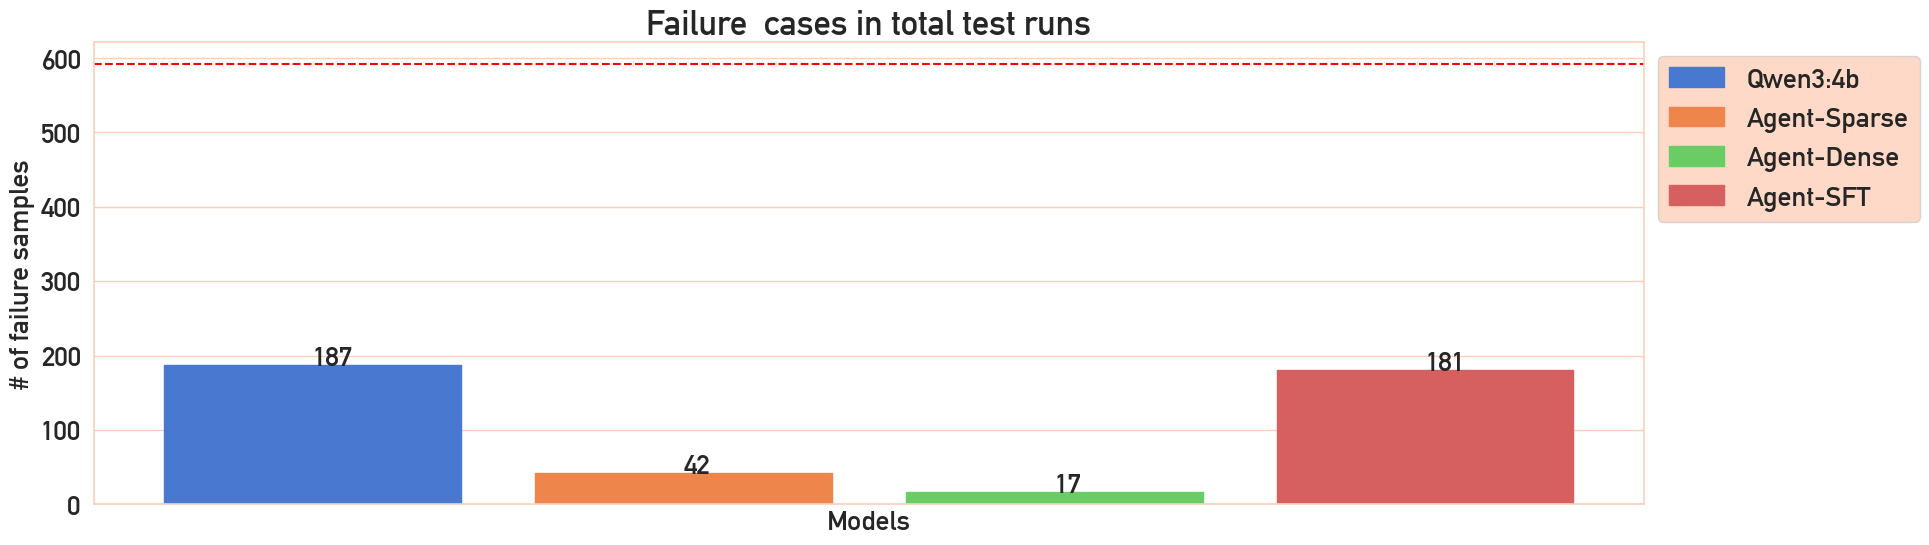

In [13]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i],size=20)

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels, edgecolor=edgecolors)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test runs")
plt.xlabel("Models")
plt.xticks([])
plt.ylabel("# of failure samples")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

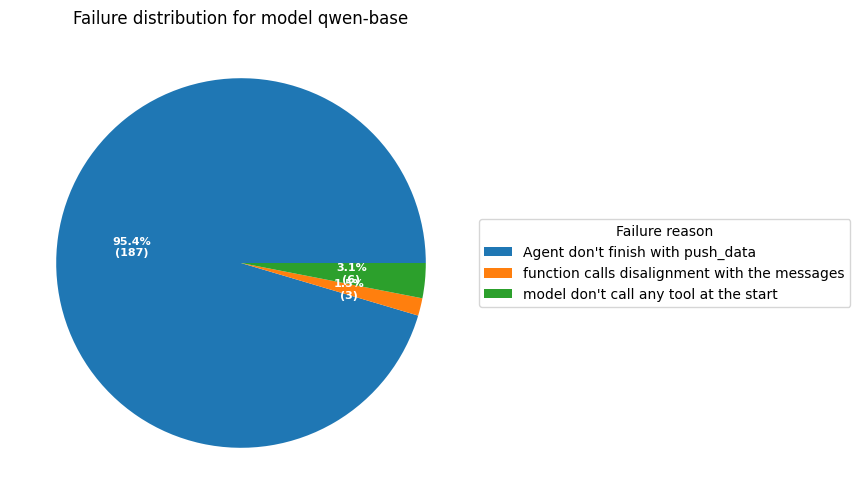

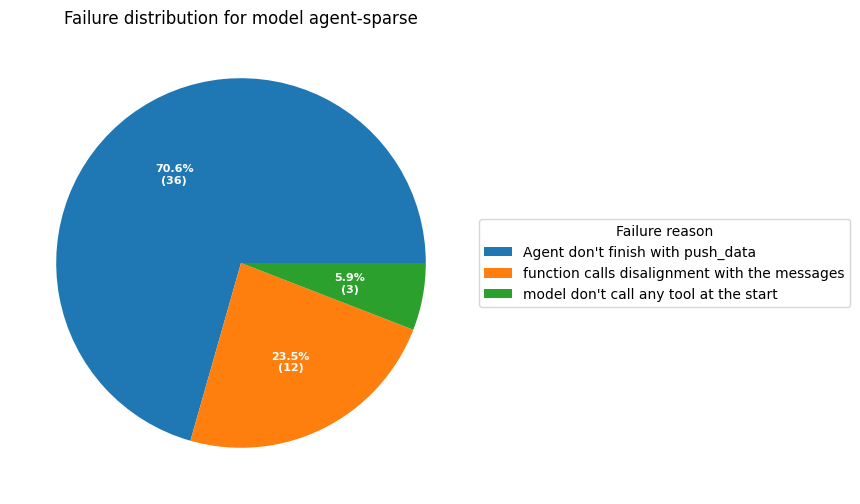

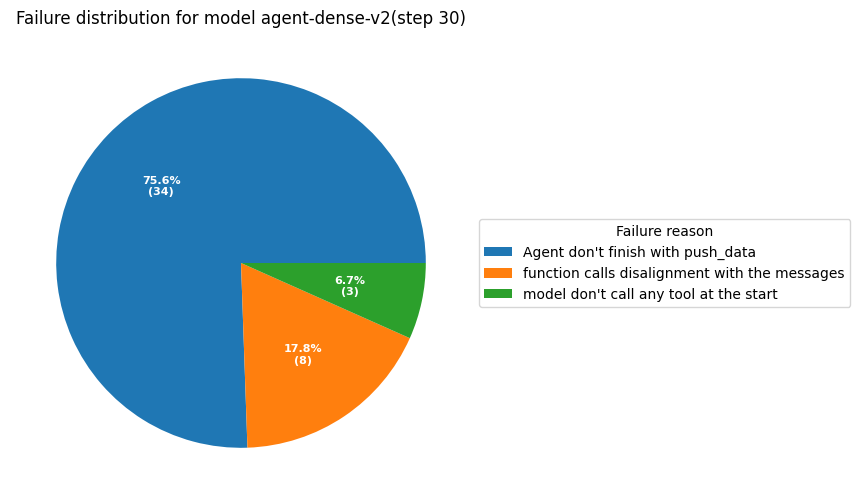

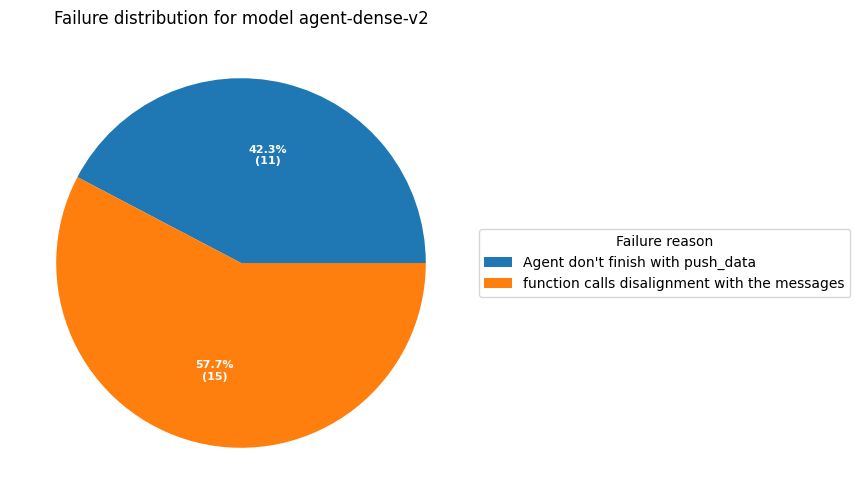

In [14]:
# pei chart sulle tipologie di failure

for model,label in zip(models,labels):
    fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))


    def func(pct,all):
        absolute = int(np.round(pct/100.*np.sum(all)))
        return f"{pct:.1f}%\n({absolute})"

    dict_results = dict(df.loc[df['model'] == model].groupby(['failure_reason'])['REF_INDICE'].count())
    data = dict_results.values()
    labels = dict_results.keys()
    wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                      textprops=dict(color="w"))

    ax.legend(wedges,labels,
              title="Failure reason",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=8, weight="bold")

    ax.set_title(f"Failure distribution for model {label}")
    plt.show()